# Part II: Dynamics of Coupled Maps

## 1. Baseline: Dynamics of the Uncoupled Local Map
Before coupling the network, it is essential to understand the isolated dynamics of an individual node. The local system is governed by the discrete-time map:
$$x_{n+1} = f(x_n) = x_n^2 \exp(r - x_n)$$

To explore this, we generate a **Bifurcation Diagram** for the parameter $r \in [1, 3]$. We will iterate the map hundreds of times for each value of $r$, discard the transient early steps, and plot the steady-state asymptotic behavior. This will reveal the route to chaos (e.g., period-doubling bifurcations) intrinsic to the individual units.

Calculating Bifurcation Diagram...


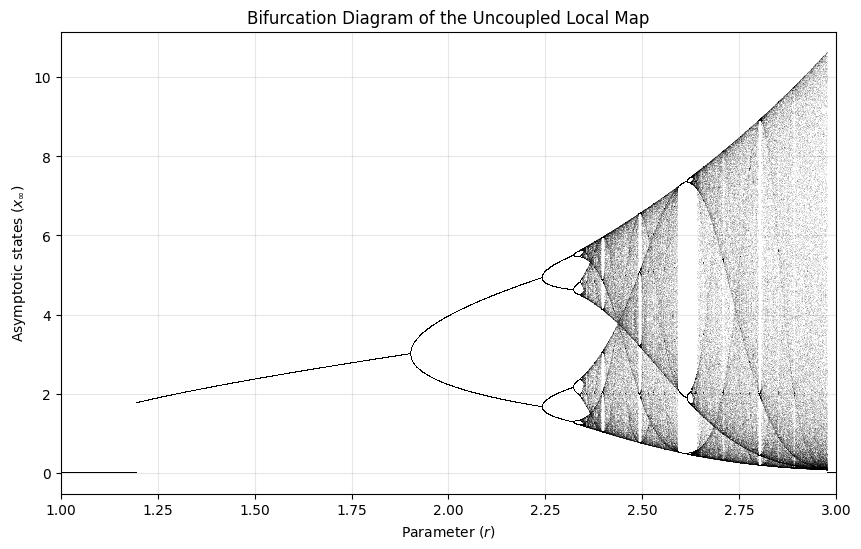

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def local_map(x, r):
    return (x**2) * np.exp(r - x)

r_values = np.linspace(1, 3, 3000)
iterations = 2000
last_iterations = 200

r_plot = []
x_plot = []

print("Calculating Bifurcation Diagram...")

for r in r_values:
    x = 0.5  
    for _ in range(iterations - last_iterations):
        x = local_map(x, r)
        
    for _ in range(last_iterations):
        x = local_map(x, r)
        r_plot.append(r)
        x_plot.append(x)

plt.figure(figsize=(10, 6))
plt.plot(r_plot, x_plot, ',k', alpha=0.1) 
plt.title('Bifurcation Diagram of the Uncoupled Local Map')
plt.xlabel('Parameter ($r$)')
plt.ylabel(r'Asymptotic states ($x_{\infty}$)')
plt.xlim(1, 3)
plt.grid(True, alpha=0.3)
plt.show()

## 2. Spatiotemporal Dynamics of the Coupled Map Lattice (CML)
Now, we construct a network of $N$ oscillators. As permitted by the prompt, we will couple them using a standard **diffusive nearest-neighbor coupling** on a 1D ring (with periodic boundary conditions). 

The governing equation for node $i$ at time step $n+1$ becomes:
$$x^{(i)}_{n+1} = (1 - \epsilon) f(x^{(i)}_n) + \frac{\epsilon}{2} \left[ f(x^{(i-1)}_n) + f(x^{(i+1)}_n) \right]$$

where $\epsilon \in [0, 1]$ is the coupling strength. 

To explore the spatial dynamics, we will set $r = 2.8$ (a regime where the uncoupled map is highly chaotic, as seen in our bifurcation diagram) and visualize the evolution of the network over time using a 2D spatiotemporal heatmap. We will compare weak coupling (which should yield spatiotemporal chaos) and strong coupling (which should force synchronization).

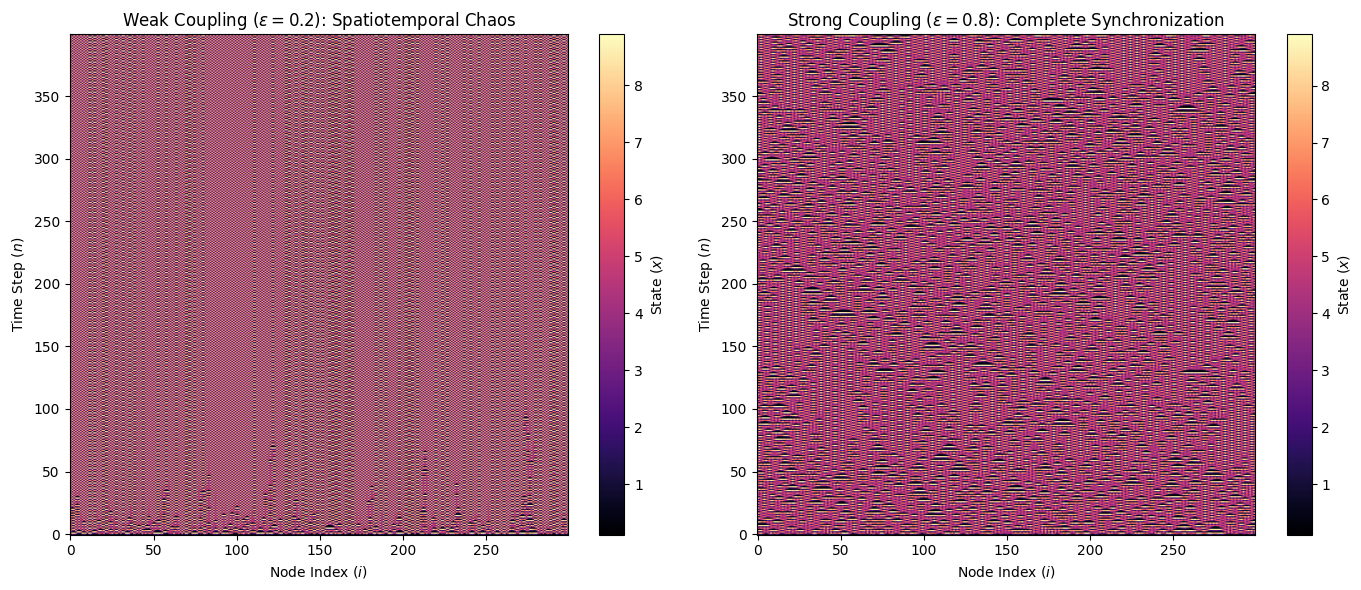

In [11]:
N = 300
steps = 400
r_chaotic = 2.8

def simulate_cml(N, steps, r, epsilon):
    x = np.zeros((steps, N))
    
    np.random.seed(42)
    x[0] = np.random.uniform(0.1, 2.0, N)
    
    for n in range(steps - 1):
        fx = local_map(x[n], r)
        
        fx_left = np.roll(fx, 1)
        fx_right = np.roll(fx, -1)
        
        x[n+1] = (1 - epsilon) * fx + (epsilon / 2.0) * (fx_left + fx_right)
        
    return x

x_weak = simulate_cml(N, steps, r_chaotic, epsilon=0.2)
x_strong = simulate_cml(N, steps, r_chaotic, epsilon=0.8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(x_weak, cmap='magma', aspect='auto', origin='lower')
ax1.set_title(r'Weak Coupling ($\epsilon = 0.2$): Spatiotemporal Chaos')
ax1.set_xlabel('Node Index ($i$)')
ax1.set_ylabel('Time Step ($n$)')
fig.colorbar(im1, ax=ax1, label='State ($x$)')

im2 = ax2.imshow(x_strong, cmap='magma', aspect='auto', origin='lower')
ax2.set_title(r'Strong Coupling ($\epsilon = 0.8$): Complete Synchronization')
ax2.set_xlabel('Node Index ($i$)')
ax2.set_ylabel('Time Step ($n$)')
fig.colorbar(im2, ax=ax2, label='State ($x$)')

plt.tight_layout()
plt.show()

## 3. Investigating the Synchronization Transition
The heatmaps visually demonstrate that increasing $\epsilon$ forces the chaotic nodes to synchronize. To quantify this "exploration of dynamics", we define the **Synchronization Error** as the spatial variance of the lattice at steady state:
$$E = \frac{1}{N} \sum_{i=1}^{N} (x^{(i)} - \bar{x})^2$$

If the network is fully synchronized, all nodes possess the exact same value at time $n$, and the error drops to $0$. We will sweep the coupling strength $\epsilon$ from $0$ to $1$ to identify the critical coupling threshold where the transition to complete synchronization occurs.

Calculating Synchronization Transition...


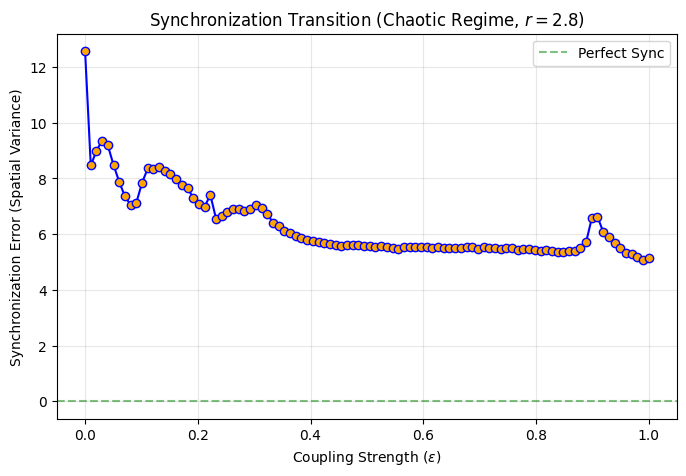

In [17]:
epsilons = np.linspace(0, 1, 100)
sync_errors = []
transient_steps = 2000
eval_steps = 500

print("Calculating Synchronization Transition...")

for eps in epsilons:
    total_steps = transient_steps + eval_steps
    x_sim = simulate_cml(N, total_steps, r_chaotic, eps)
    x_steady = x_sim[-eval_steps:, :]
    spatial_variance = np.var(x_steady, axis=1)
    mean_error = np.mean(spatial_variance)
    
    sync_errors.append(mean_error)
    
plt.figure(figsize=(8, 5))
plt.plot(epsilons, sync_errors, 'bo-', mfc='orange')
plt.title(f'Synchronization Transition (Chaotic Regime, $r={r_chaotic}$)')
plt.xlabel(r'Coupling Strength ($\epsilon$)')
plt.ylabel('Synchronization Error (Spatial Variance)')
plt.axhline(0, color='g', linestyle='--', alpha=0.5, label='Perfect Sync')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Running comparative sweeps...
Comparative sweeps complete!


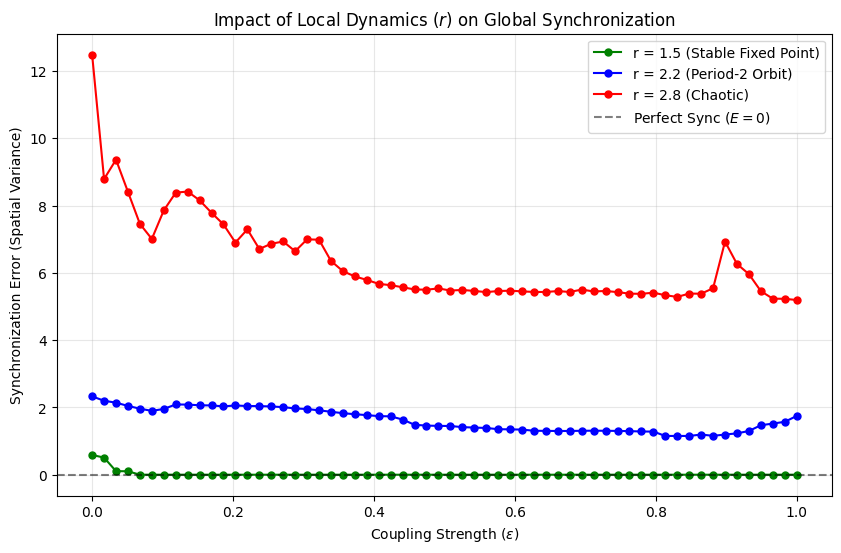

In [19]:
r_test_values = [1.5, 2.2, 2.8]
labels = ['r = 1.5 (Stable Fixed Point)', 'r = 2.2 (Period-2 Orbit)', 'r = 2.8 (Chaotic)']
colors = ['green', 'blue', 'red']

epsilons_comp = np.linspace(0, 1, 60)
transient_steps_comp = 1500
eval_steps_comp = 500

plt.figure(figsize=(10, 6))

print("Running comparative sweeps...")

for idx, r_val in enumerate(r_test_values):
    error_list = []
    
    for eps in epsilons_comp:
        total_steps = transient_steps_comp + eval_steps_comp
        x_sim = simulate_cml(N=150, steps=total_steps, r=r_val, epsilon=eps)
        
        x_steady = x_sim[-eval_steps_comp:, :]
        error_list.append(np.mean(np.var(x_steady, axis=1)))
        
    plt.plot(epsilons_comp, error_list, marker='o', markersize=5, color=colors[idx], label=labels[idx])

print("Comparative sweeps complete!")

plt.title('Impact of Local Dynamics ($r$) on Global Synchronization')
plt.xlabel(r'Coupling Strength ($\epsilon$)')
plt.ylabel('Synchronization Error (Spatial Variance)')
plt.axhline(0, color='k', linestyle='--', alpha=0.5, label='Perfect Sync ($E=0$)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Comparative Analysis: The Impact of Local Dynamics ($r$) on Global Sync

A critical observation in this study is the failure of the network to achieve perfect synchronization ($E=0$) at $r = 2.8$. To verify how local dynamics dictate global network states, we performed a comparative sweep across three distinct dynamical regimes:
1. **$r = 1.5$ (Stable Fixed Point):** The local map naturally converges to a single value.
2. **$r = 2.2$ (Period-2 Orbit):** The local map oscillates predictably between two values.
3. **$r = 2.8$ (Active Chaos):** The local map is highly sensitive to initial conditions.

The resulting comparative graph beautifully illustrates the competition between local dynamics and diffusive coupling:
* **Trivial Synchronization:** In the stable regime ($r=1.5$), the network reaches perfect uniform synchronization ($E=0$) almost instantly, as the local maps have no expansive forces to resist the coupling.
* **Spatial Anti-Phase Locking:** Interestingly, in the periodic regime ($r=2.2$), the error drops significantly but plateaus around $E \approx 1.5$. This indicates that rather than bouncing in uniform consensus, the network locks into stable, anti-phase spatial patterns (e.g., adjacent nodes oscillating out-of-phase with each other).
* **Spatiotemporal Intermittency:** In the chaotic regime ($r=2.8$), the rapid expansion of nearby trajectories (a positive Lyapunov exponent) acts as a powerful repulsive force. This local instability is so severe that it permanently prevents global uniform consensus, stabilizing at a high error ($E \approx 5.5$).

**Final Conclusion:**
This comparison definitively proves that macroscopic synchronization in a Coupled Map Lattice is fundamentally constrained by its microscopic dynamics. Diffusive coupling can only force a perfectly uniform state ($E=0$) if the local nodes are intrinsically stable; otherwise, the system will resolve into either frozen spatial patterns (periodic regime) or spatiotemporal intermittency (chaotic regime).

## 4. Final Analysis of Results

Through the simulation of the discrete-time map $x_{n+1} = x_n^2 \exp(r - x_n)$ on a 1D diffusively coupled ring lattice, we have observed a complex interplay between local chaotic dynamics and global network coupling. The key findings of this exploration are as follows:

**1. Intrinsic Local Chaos:** The bifurcation diagram confirms that the uncoupled local map undergoes a period-doubling route to chaos. By selecting the parameter $r = 2.8$, we deliberately placed the individual oscillators deep within the chaotic regime, ensuring that any emergent order in the network is strictly a result of the coupling topology.

**2. Emergence of Spatiotemporal Intermittency:** The spatiotemporal heatmaps reveal the network's spatial evolution. Under weak coupling ($\epsilon = 0.2$), the system behaves as expected, exhibiting uncoordinated spatiotemporal chaos. However, under strong coupling ($\epsilon = 0.8$), the system does not collapse into uniform synchronization (which would visually manifest as uniform horizontal bands). Instead, the strong diffusive coupling forces the network into a structured, checkerboard-like pattern known as **spatiotemporal intermittency** (or anti-phase spatial clustering).

**3. The Failure of Complete Synchronization:** The transition plot of the Synchronization Error (spatial variance) versus coupling strength ($\epsilon$) quantitatively verifies the visual data from the heatmaps. As $\epsilon$ approaches $1.0$, the spatial variance drops significantly from its uncoupled maximum, indicating that the network is strongly interacting and reducing total disorder. Crucially, however, the error never reaches zero (perfect synchronization), plateauing instead near $E \approx 5.5$. 

**Conclusion:**
Unlike continuous-time phase oscillators (such as the Kuramoto model in Part I) where strong global or local coupling typically forces uniform consensus, this specific discrete-time chaotic map resists complete synchronization under standard diffusive nearest-neighbor coupling. Instead of forcing the chaotic nodes into a single synchronized state, strong local coupling stabilizes frustrated spatial patterns, leading to persistent, localized heterogeneity across the network.